# EN3160 — Assignment 01

## Intensity Transformations and Neighborhood Filtering

**Deshan W.U.**  
**230130E**

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [2]:
emma = cv.imread('images/emma.jpeg', cv.IMREAD_GRAYSCALE)# Import Emma image
assert emma is not None
t1 = np.linspace(0, 50, num=51).astype('uint8')# Define piecewise transformation function
t2 = np.linspace(100, 255, num=100).astype('uint8')
t3 = np.linspace(150, 255, num=105).astype('uint8')
t = np.concatenate((t1, t2, t3), axis=0).astype('uint8')# Concatenate all segments to create the transformation array
print(t.shape)

(256,)


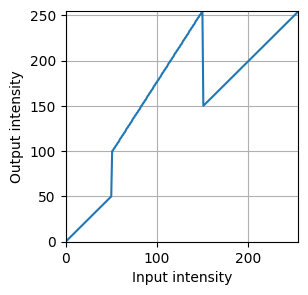

In [3]:
plt.figure(figsize=(3, 3))#Plot the transformation
plt.plot(t),plt.xlabel("Input intensity"),plt.ylabel("Output intensity")
plt.xlim(0, 255),plt.ylim(0, 255)
plt.grid(True)
plt.show()

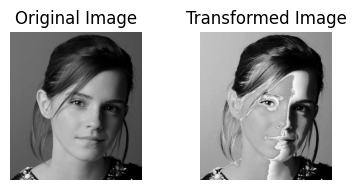

In [4]:
g = t[emma]
plt.figure(figsize=(4, 2))
plt.subplot(1, 2, 1)
plt.imshow(emma, cmap='gray', vmin=0, vmax=255)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis('off')
plt.tight_layout()
plt.show()

The transformation enhances the contrast of the image by modifying the intensity levels of selected pixels. The low- and high-intensity regions remain mostly unchanged, while the mid-intensity pixels are enhanced, resulting in clearer and more distinct features in the output image.

### Question 2

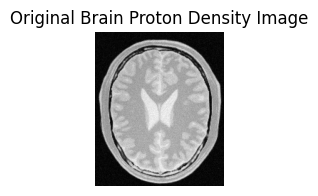

In [5]:
brain = cv.imread('images/brain.png', cv.IMREAD_GRAYSCALE)# Import brain image
assert brain is not None
plt.figure(figsize=(2, 2))# Display original image
plt.imshow(brain, cmap='gray', vmin=0, vmax=255)
plt.title("Original Brain Proton Density Image")
plt.axis("off")
plt.show()

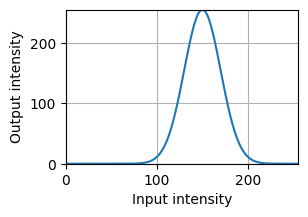

In [6]:
#a) white matter
mu = 150
sigma = 20
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))
t = np.clip(t, 0, 255)# Ensure the output is in the valid range for image intensities [0, 255]
plt.figure(figsize=(3, 2))# Plot the array
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

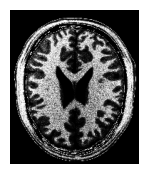

In [7]:
g = t[brain]
plt.figure(figsize=(2, 2))# Display the image
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

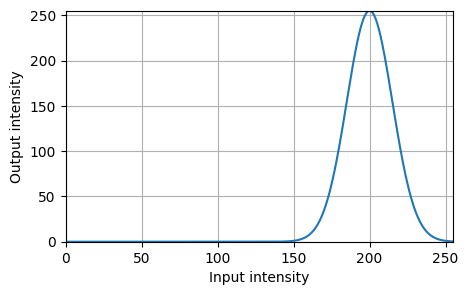

In [9]:
#b) gray matter
mu = 200
sigma = 15
x = np.linspace(0, 255, 256)
t = 255 * np.exp(-((x - mu)**2) / (2 * sigma**2))
t = np.clip(t, 0, 255)# Ensure the output is in the valid range for image intensities [0, 255]
plt.figure(figsize=(5, 3))# Plot the array
plt.plot(t)
plt.xlabel("Input intensity")
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.ylabel("Output intensity")
plt.grid(True)
plt.show()

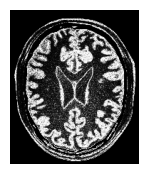

In [10]:
g = t[brain]# Apply transformation
plt.figure(figsize=(2, 2))# Display transformed image
plt.imshow(g, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### Question 3

In [11]:
girl = cv.imread('images/girl.jpeg')# Import  image
assert girl is not None
lab = cv.cvtColor(girl, cv.COLOR_BGR2LAB)
girl_rgb = cv.cvtColor(girl, cv.COLOR_BGR2RGB)
L, a, b = cv.split(lab)
L_norm = L.astype(np.float32) / 255.0

In [12]:
gamma = 0.75#Apply gamma correction
L_corrected = np.power(L_norm, gamma)
L_corrected = np.clip(L_corrected * 255,0,255).astype(np.uint8)
lab_corrected = lab.copy()
lab_corrected[:, :, 0] = L_corrected
rgb_corrected = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)

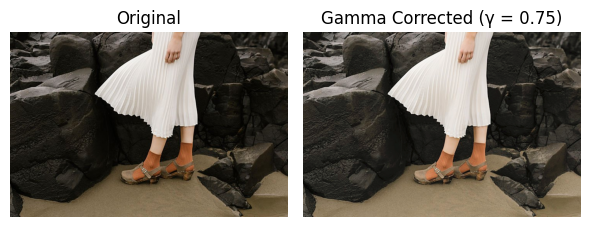

In [14]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(girl_rgb)
plt.title("Original")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(rgb_corrected)
plt.title(f"Gamma Corrected (γ = {gamma})")
plt.axis("off")
plt.tight_layout()
plt.show()

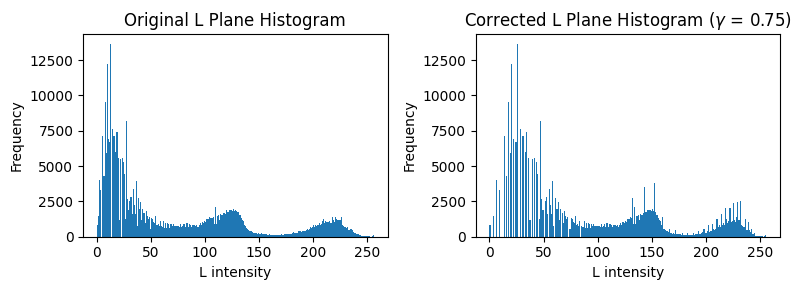

In [16]:
plt.figure(figsize=(8, 3))# Histograms of L plane before and after gamma correction
plt.subplot(1, 2, 1)# Original L plane histogram
plt.hist(L.ravel(),bins=256,range=(0, 256))
plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title("Original L Plane Histogram")
plt.subplot(1, 2, 2)# L plane histogram after gamma correction
plt.hist(L_corrected.ravel(),bins=256,range=(0, 256))
plt.xlabel("L intensity")
plt.ylabel("Frequency")
plt.title(f"Corrected L Plane Histogram ($\\gamma$ = {gamma})")
plt.tight_layout()
plt.show()

Gamma correction is a non-linear transformation that redistributes pixel intensities. This can amplify small intensity differences and introduce quantization noise, making the histogram appear more uneven or noisy.

### Question 4

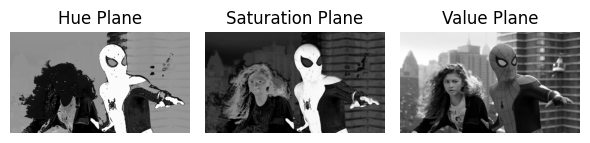

In [17]:
peter = cv.imread('images/peter.png')# Import image
assert peter is not None
peter_hsv = cv.cvtColor(peter, cv.COLOR_BGR2HSV)
peter_rgb = cv.cvtColor(peter, cv.COLOR_BGR2RGB)
H, S, V = cv.split(peter_hsv)# Split into planes
fig, axs = plt.subplots(1, 3, figsize=(6, 2))# Display the planes
axs[0].imshow(H, cmap='gray')
axs[0].set_title('Hue Plane')
axs[0].axis('off')
axs[1].imshow(S, cmap='gray')
axs[1].set_title('Saturation Plane')
axs[1].axis('off')
axs[2].imshow(V, cmap='gray')
axs[2].set_title('Value Plane')
axs[2].axis('off')
plt.tight_layout()
plt.show()

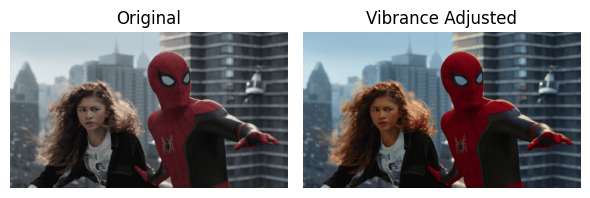

In [18]:
a = 0.7
sigma = 70.0 # Define the transformation function
x = np.arange(0, 256)
f = np.minimum(x + a * 128 * np.exp(-((x - 128)**2) / (2 * sigma**2)), 255).astype('uint8')
S_modified = cv.LUT(S, f)# Apply transformation to Saturation plane
merged = cv.merge([H, S_modified, V])# Merge H, modified S, and V planes
peter_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)# Convert HSV to RGB
fig, axs = plt.subplots(1, 2, figsize=(6, 2))# Create a figure and axes
axs[0].imshow(peter_rgb)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(peter_modified)
axs[1].set_title('Vibrance Adjusted')
axs[1].axis('off')
plt.tight_layout()
plt.show()

By fine-tuning the parameter a, several values were tested to obtain a visually pleasing output. After comparing the resulting images, a = 0.6 was selected as the best value. This value provided an appropriate enhancement of the image saturation while maintaining a natural appearance.

### Question 5

In [19]:
beans = cv.imread('images/beans.png', cv.IMREAD_GRAYSCALE)# Import Shells image
assert beans is not None
def histogram_equalization(f):
    L = 256
    M, N = f.shape
    hist = cv.calcHist([f], [0], None, [L], [0, L])
    cdf = hist.cumsum()
    t = np.array([(L-1)/(M*N)*cdf[k]
                   for k in range(256)]).astype("uint8") # Define transformation
    return t[f]

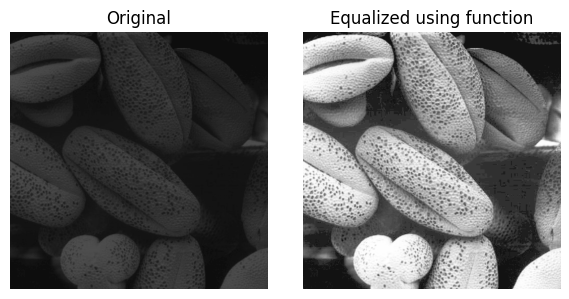

In [21]:
equalized = histogram_equalization(beans)# Do histrogram equalization
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(beans, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original')
ax[0].axis("off")
ax[1].imshow(equalized, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Equalized using function')
ax[1].axis("off")
plt.tight_layout()
plt.show()

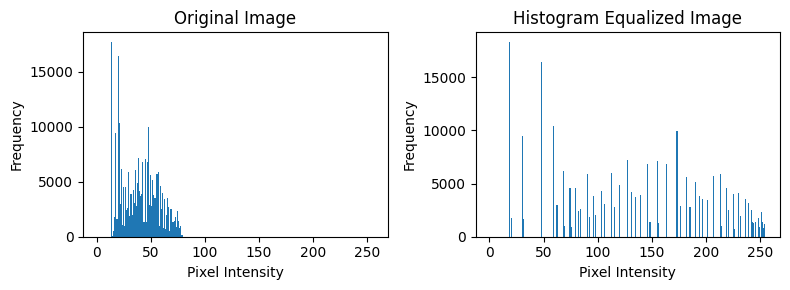

In [23]:
# Display histograms
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].hist(beans.ravel(), bins=256, range=(0, 256))
ax[0].set_title('Original Image')
ax[0].set_xlabel('Pixel Intensity')
ax[0].set_ylabel('Frequency')
ax[1].hist(equalized.ravel(), bins=256, range=(0, 256))
ax[1].set_title('Histogram Equalized Image')
ax[1].set_xlabel('Pixel Intensity')
ax[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

The histogram is more evenly distributed after equalization, improving image contrast. However, some quantization noise is introduced, while the low-intensity peaks remain mostly unchanged.

### Question 6

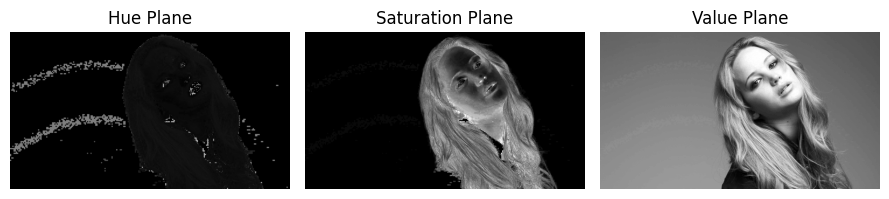

In [24]:
jennifer = cv.imread('images/jennifer.jpeg')# a) Read the image
assert jennifer is not None
hsv = cv.cvtColor(jennifer, cv.COLOR_BGR2HSV)# Convert BGR image to HSV
H, S, V = cv.split(hsv)
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
ax[0].imshow(H, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Hue Plane')
ax[0].axis('off')
ax[1].imshow(S, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Saturation Plane')
ax[1].axis('off')
ax[2].imshow(V, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Value Plane')
ax[2].axis('off')
plt.tight_layout()
plt.show()

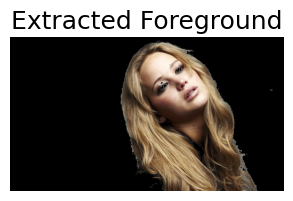

In [25]:
_, mask = cv.threshold(S, 12, 255, cv.THRESH_BINARY)# b) Apply thresholding on Saturation plane
foreground = cv.bitwise_and(jennifer, jennifer, mask=mask)# Use bitwise_and to extract the foreground using the mask
plt.figure(figsize=(6, 2))# Display the extracted foreground
plt.imshow(cv.cvtColor(foreground, cv.COLOR_BGR2RGB))
plt.title('Extracted Foreground', fontsize=18)
plt.axis('off')
plt.show()

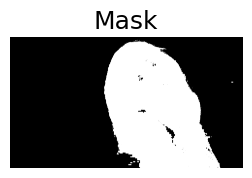

In [26]:
plt.figure(figsize=(3, 2))#c)
plt.imshow(mask, cmap='gray'),plt.title('Mask', fontsize=18),plt.axis('off')
plt.show()

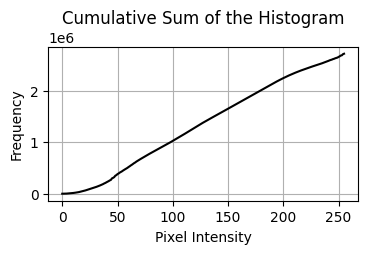

In [28]:
hist = cv.calcHist([V], [0], mask, [256], [0, 256])# d) Calculate the cumulative sum of the histogram
cdf = hist.cumsum()
plt.figure(figsize=(4, 2))
plt.plot(cdf, color='black')
plt.title('Cumulative Sum of the Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

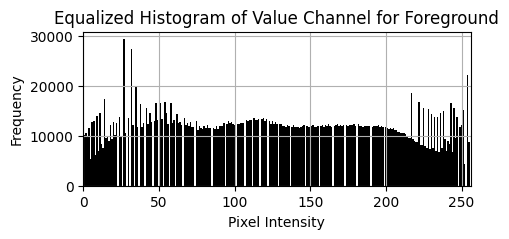

In [29]:
pixels = cdf[-1]# e) Calculate the histogram of the Value channel
t = np.array([(256-1)/(pixels)*cdf[k] for k in range(256)]).astype("uint8")
V_eq = t[V]
hist = cv.calcHist([V_eq], [0], mask, [256], [0, 256])# Calculate the histogram of the equalized Value channel
x_positions = np.arange(len(hist))# Create an array for the x positions of the bars
plt.figure(figsize=(5, 2))
plt.bar(x_positions, hist.flatten(), color='black', width=1) 
plt.title('Equalized Histogram of Value Channel for Foreground')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.xlim([0, 256])
plt.grid(True)
plt.show()

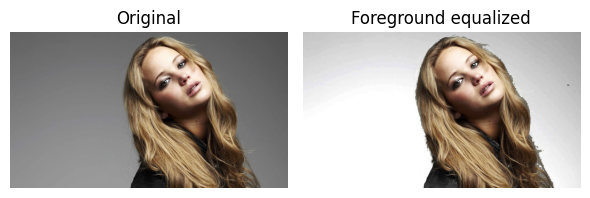

In [30]:
merged = cv.merge([H, S, V])
foreground_modified = cv.cvtColor(merged, cv.COLOR_HSV2RGB)
background = cv.bitwise_and(jennifer, jennifer, mask=cv.bitwise_not(mask))# Extract the background
result = cv.add(cv.cvtColor(background, cv.COLOR_BGR2RGB), foreground_modified)
fig, axs = plt.subplots(1, 2, figsize=(6, 2))# Create a figure and axes
axs[0].imshow(cv.cvtColor(jennifer, cv.COLOR_BGR2RGB))
axs[0].set_title('Original')
axs[0].axis('off') 
axs[1].imshow(result)
axs[1].set_title('Foreground equalized')
axs[1].axis('off') 
plt.tight_layout()
plt.show()

Foreground equalization increased the number of dark pixels, resulting in darker shadows below the face, as observed in the output image.

### Question 7

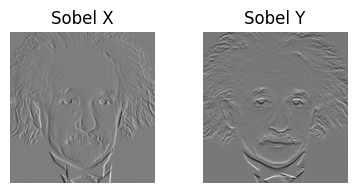

In [31]:
albert = cv.imread('images/albert.png', cv.IMREAD_GRAYSCALE)# Import Einstein image
assert albert is not None
sobel_x = np.array([[1, 0, -1], [2, 0, -2],[1, 0, -1]])# a) Define the Sobel-X filter
sobel_y = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]])# Define the Sobel-Y filter
sobel_x_filtered = cv.filter2D(albert, cv.CV_64F, sobel_x)
sobel_y_filtered = cv.filter2D(albert, cv.CV_64F, sobel_y)
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].imshow(sobel_x_filtered, cmap='gray')
ax[0].set_title('Sobel X')
ax[0].axis('off')
ax[1].imshow(sobel_y_filtered, cmap='gray')
ax[1].set_title('Sobel Y')
ax[1].axis('off')
plt.tight_layout()
plt.show()

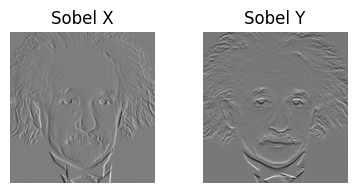

In [32]:
# b)
def apply_filter(image, filter):
    [rows, columns] = np.shape(image)
    filtered_image = np.zeros(shape=(rows, columns))
    for i in range(rows - 2):
        for j in range(columns - 2):
            value = np.sum(np.multiply(filter, image[i:i + 3, j:j + 3]))
            filtered_image[i + 1, j + 1] = value
    return filtered_image
sobel_x = np.array([[1, 0, -1],[2, 0, -2],[1, 0, -1]])
sobel_y = np.array([[1, 2, 1],[0, 0, 0],[-1, -2, -1]])
sobel_x_filtered = cv.filter2D(albert, cv.CV_64F, sobel_x)
sobel_y_filtered = cv.filter2D(albert, cv.CV_64F, sobel_y)
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].imshow(sobel_x_filtered, cmap='gray')
ax[0].set_title('Sobel X')
ax[0].axis('off')
ax[1].imshow(sobel_y_filtered, cmap='gray')
ax[1].set_title('Sobel Y')
ax[1].axis('off')
plt.tight_layout()
plt.show()

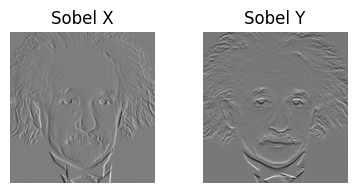

In [33]:
sobel_x_v = np.array([[1], [2], [1]])#c) Separated Sobel filters
sobel_x_h = np.array([[1, 0, -1]])
sobel_y_v = np.array([[1], [0], [-1]])
sobel_y_h = np.array([[1, 2, 1]])
x_filtered = cv.filter2D(cv.filter2D(albert, cv.CV_64F, sobel_x_h),cv.CV_64F, sobel_x_v)
y_filtered = cv.filter2D( cv.filter2D(albert, cv.CV_64F, sobel_y_v),cv.CV_64F, sobel_y_h)
fig, ax = plt.subplots(1, 2, figsize=(4, 2))
ax[0].imshow(x_filtered, cmap='gray')
ax[0].set_title('Sobel X')
ax[0].axis('off')
ax[1].imshow(y_filtered, cmap='gray')
ax[1].set_title('Sobel Y')
ax[1].axis('off')
plt.tight_layout()
plt.show()

## Question 8

In [35]:
def zoom(img, technique, scale=4):
    if technique == 'nn':
        return cv.resize(img, None, fx=scale, fy=scale, interpolation=cv.INTER_NEAREST)
    elif technique == 'bilinear':
        return cv.resize(img, None, fx=scale, fy=scale, interpolation=cv.INTER_LINEAR)

def norm_SSD(img1, img2):
    if img1.shape != img2.shape:
        raise ValueError("Images must have the same dimensions")
    return np.sum((img1 - img2)**2) / img1.size

In [36]:
# Import images 01 and 01small
im1 = cv.imread('images/im01.png')
assert im1 is not None
im1_small = cv.imread('images/im01small.png')
assert im1_small is not None

In [37]:
im1_zoomed_nn = zoom(im1_small, technique='nn')
im1_zoomed_bilinear = zoom(im1_small, technique='bilinear')

nn_SSD = norm_SSD(im1, im1_zoomed_nn)
bilinear_SSD = norm_SSD(im1, im1_zoomed_bilinear)

print('Normalized SSD for Nearest Neighbour: ', nn_SSD)
print('Normalized SSD for Bilinear: ', bilinear_SSD)

Normalized SSD for Nearest Neighbour:  31.284316486625514
Normalized SSD for Bilinear:  31.053094618055557


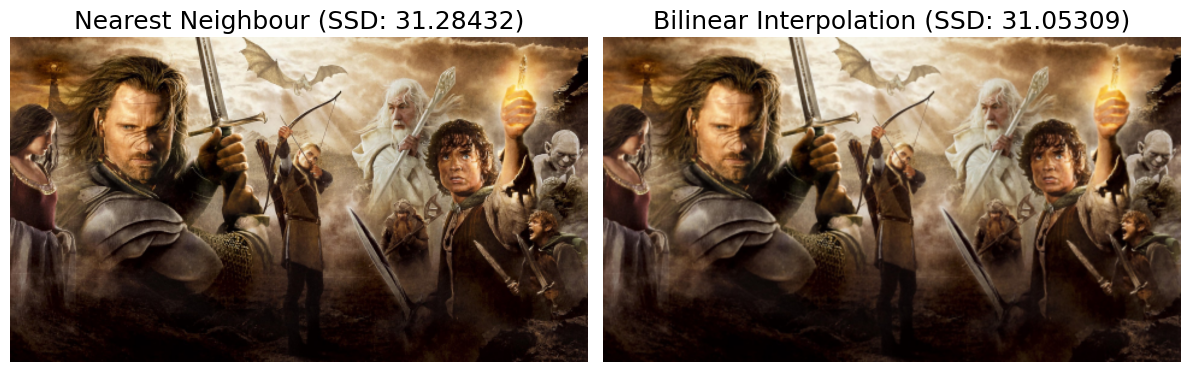

In [38]:
# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(12, 8))
# Plot the second image
axs[0].imshow(cv.cvtColor(im1_zoomed_nn, cv.COLOR_BGR2RGB))
axs[0].set_title(f'Nearest Neighbour (SSD: {nn_SSD:.5f})', fontsize=18)
axs[0].axis('off')  # Turn off the axis
# Plot the second image
axs[1].imshow(cv.cvtColor(im1_zoomed_bilinear, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Bilinear Interpolation (SSD: {bilinear_SSD:.5f})', fontsize=18)
axs[1].axis('off')  # Turn off the axis
# Show the plot
plt.tight_layout()
plt.show()

In [39]:
# Import images 02 and 02small
im2 = cv.imread('images/im02.png')
assert im2 is not None
im2_small = cv.imread('images/im02small.png')
assert im2_small is not None

In [40]:
im2_zoomed_nn = zoom(im2_small, technique='nn')
im2_zoomed_bilinear = zoom(im2_small, technique='bilinear')
nn_SSD = norm_SSD(im2, im2_zoomed_nn)
bilinear_SSD = norm_SSD(im2, im2_zoomed_bilinear)
print('Normalized SSD for Nearest Neighbour: ', nn_SSD)
print('Normalized SSD for Bilinear: ', bilinear_SSD)

Normalized SSD for Nearest Neighbour:  11.902013310185184
Normalized SSD for Bilinear:  10.682991753472223


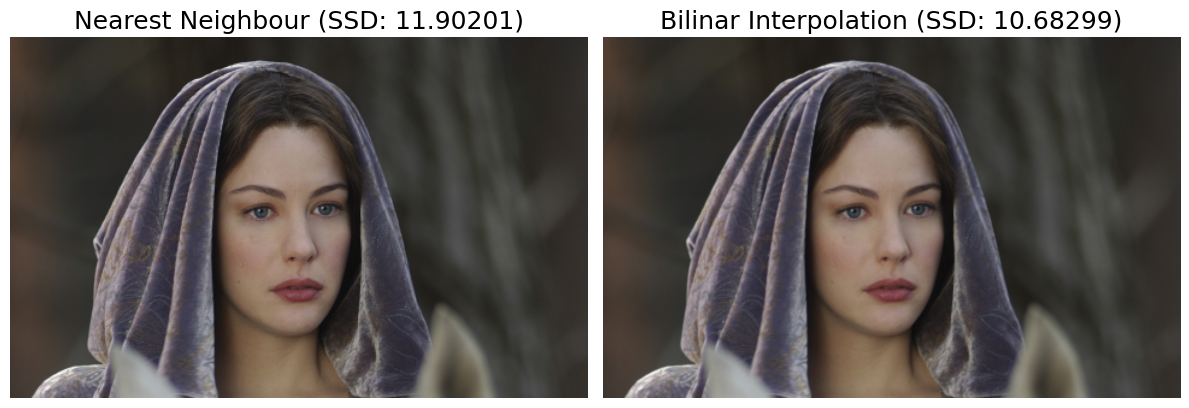

In [41]:
# Create a figure and axes
fig, axs = plt.subplots(1, 2, figsize=(12, 8))
# Plot the second image
axs[0].imshow(cv.cvtColor(im2_zoomed_nn, cv.COLOR_BGR2RGB))
axs[0].set_title(f'Nearest Neighbour (SSD: {nn_SSD:.5f})', fontsize=18)
axs[0].axis('off')  # Turn off the axis
# Plot the second image
axs[1].imshow(cv.cvtColor(im2_zoomed_bilinear, cv.COLOR_BGR2RGB))
axs[1].set_title(f'Bilinar Interpolation (SSD: {bilinear_SSD:.5f})', fontsize=18)
axs[1].axis('off')  # Turn off the axis
# Show the plot
plt.tight_layout()
plt.show()

### Question 9

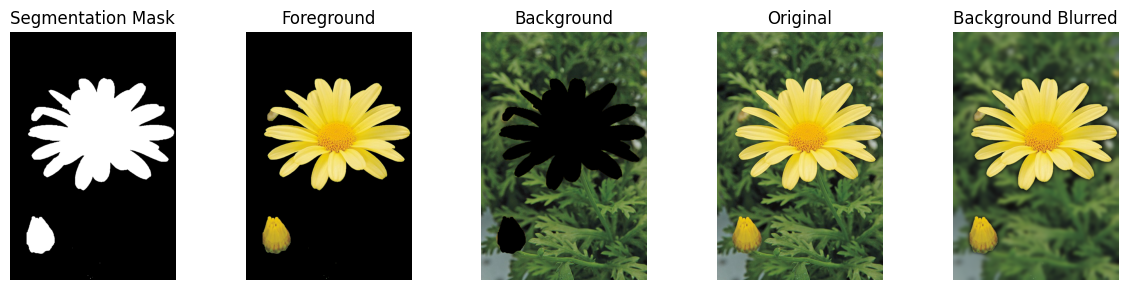

In [9]:
daisy = cv.imread("images/flower.jpeg")
img_rgb = cv.cvtColor(daisy, cv.COLOR_BGR2RGB)
mask = np.zeros(daisy.shape[:2], np.uint8)#(a) GrabCut Segmentation , Initialize mask and models
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)
h, w = daisy.shape[:2]
rect = (int(0.1*w), int(0.1*h), int(0.9*w), int(0.9*h))
cv.grabCut(daisy, mask, rect, bgdModel, fgdModel, 5, cv.GC_INIT_WITH_RECT)# Apply GrabCut
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')# Create binary foreground mask
foreground = img_rgb * mask2[:, :, np.newaxis]# Extract foreground and background
background = img_rgb * (1 - mask2[:, :, np.newaxis])# (b) Blur Background 
blurred = cv.GaussianBlur(background, (35, 35), 0)
mask3 = mask2[:, :, np.newaxis]
result = img_rgb * mask3 + blurred * (1 - mask3)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(mask2, cmap='gray'),axes[0].set_title("Segmentation Mask"),axes[0].axis("off")
axes[1].imshow(foreground),axes[1].set_title("Foreground"),axes[1].axis("off")
axes[2].imshow(background),axes[2].set_title("Background"),axes[2].axis("off")
axes[3].imshow(img_rgb),axes[3].set_title("Original"),axes[3].axis("off")
axes[4].imshow(result.astype(np.uint8)),axes[4].set_title("Background Blurred"),axes[4].axis("off")
plt.tight_layout()
plt.show()

c)The background just beyond the edge of the flower appears dark because the GrabCut segmentation mask is not perfectly accurate around the flower boundary. Some background pixels near the flower are classified as foreground, while other pixels may be excluded. Since the background image is created by multiplying the image with the inverse mask, the incorrectly classified pixels become black, producing a dark region or halo around the flower.

### Question 10

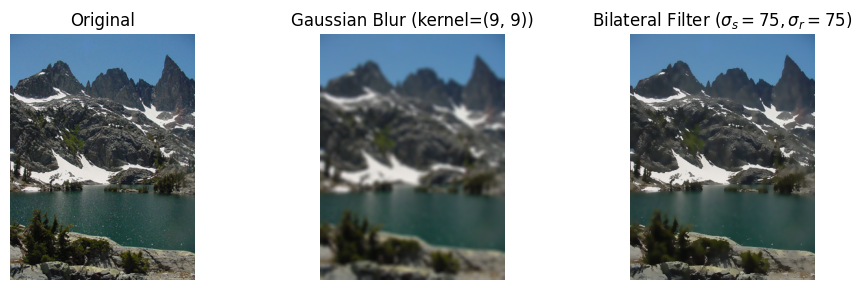

In [14]:
lake = cv.imread("images/lake.jpeg")
img_rgb = cv.cvtColor(lake, cv.COLOR_BGR2RGB)
sigma_s = 75# Filter parameters
sigma_r = 75
ksize = (9, 9)
bilateral = cv.bilateralFilter(img_rgb,d=9,sigmaColor=sigma_r,sigmaSpace=sigma_s)# Bilateral filter
gaussian = cv.GaussianBlur(img_rgb,ksize,sigmaX=sigma_r / 25)
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(img_rgb),axes[0].set_title("Original"),axes[0].axis("off")
axes[1].imshow(gaussian),axes[1].set_title(f"Gaussian Blur (kernel={ksize})"),axes[1].axis("off")
axes[2].imshow(bilateral),axes[2].set_title(f"Bilateral Filter ($\\sigma_s={sigma_s}, \\sigma_r={sigma_r}$)")
axes[2].axis("off")
plt.tight_layout()
plt.show()

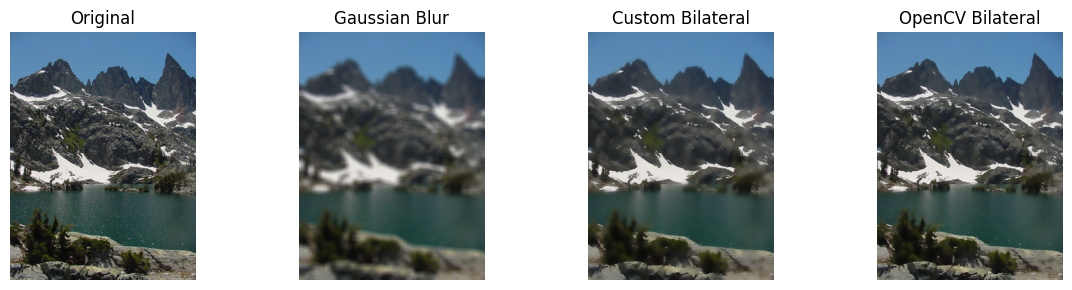

In [18]:
d = 9
sigma_s = 75
sigma_r = 75
def my_bilateral(img, d, sigma_s, sigma_r):# Custom bilateral filter 
    img = img.astype(np.float64) 
    r = d // 2 
    pad = np.pad(img, ((r,r),(r,r),(0,0)), mode='reflect') 
    x, y = np.meshgrid(np.arange(-r,r+1), np.arange(-r,r+1)) 
    spatial = np.exp(-(x**2 + y**2)/(2*sigma_s**2)) 
    result = np.zeros_like(img) 
    weights_sum = np.zeros(img.shape[:2] + (1,)) 
    for i in range(d): 
        for j in range(d): 
            shifted = pad[i:i+img.shape[0], j:j+img.shape[1]] 
            diff = shifted - img 
            dist = np.sum(diff**2, axis=2, keepdims=True) 
            range_w = np.exp(-dist/(2*sigma_r**2)) 
            weight = spatial[i,j] * range_w 
            result += weight * shifted 
            weights_sum += weight 
    return np.clip(result / (weights_sum + 1e-8), 0, 255).astype(np.uint8) 
custom = my_bilateral(lake, d, sigma_s, sigma_r) 
opencv = cv.bilateralFilter(lake, d, sigma_r, sigma_s) 
gaussian = cv.GaussianBlur(lake, (d,d), sigma_s) 
fig, ax = plt.subplots(1,4, figsize=(12,3)) 
ax[0].imshow(img_rgb),ax[0].set_title("Original") 
ax[1].imshow(cv.cvtColor(gaussian, cv.COLOR_BGR2RGB)),ax[1].set_title("Gaussian Blur") 
ax[2].imshow(cv.cvtColor(custom, cv.COLOR_BGR2RGB)),ax[2].set_title("Custom Bilateral") 
ax[3].imshow(cv.cvtColor(opencv, cv.COLOR_BGR2RGB)),ax[3].set_title("OpenCV Bilateral") 
for a in ax:a.axis("off") 
plt.tight_layout() 
plt.show()